# Time to get you hands dirty! Position of a star

You measure the position of a star N times with the same telescope i.e. errors are homoscedastic. Let's say the underlying process is Gaussian, the true position is 
$\mu$ = 1 (in suitable units), and the errors are $\sigma = $ 0.2


## Part 1
- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu, \sigma)$
- Plot each of the individual likelihoods separately. Also plot their product (i.e. the likelihood of the dataset {$x_i$}). Make sure the x grid has enough points.
- Just read off the maximum likelihood solution (e.g. using np.argsort)
- Compare it with the MLE estimator derived above

In [133]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats

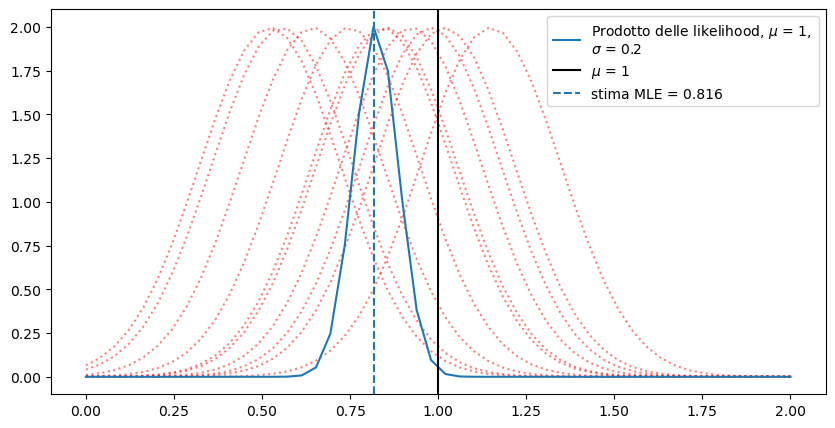

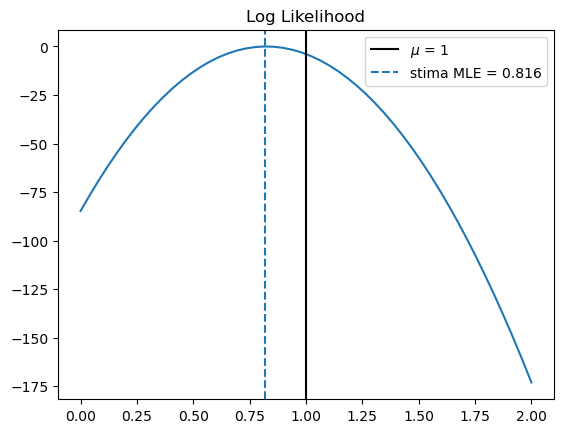

In [273]:
sigma = 0.2
mu = 1
N = 10

measure = np.random.normal(mu, sigma, N)
fix, ax = plt.subplots(figsize = (10,5))

prod = 1
xplot = np.linspace(0, 2, 50)

for i in measure:
    like = norm(i, sigma)
    plt.plot(xplot, like.pdf(xplot), ls = 'dotted', c = 'red', alpha = 0.5)
    prod = prod*like.pdf(xplot)

prod = prod/np.max(prod)

indices = np.argsort(prod)
max_index = indices[-1]
solution = xplot[max_index]

plt.plot(xplot, prod*2, label = f'Prodotto delle likelihood, $\mu$ = {mu}, \n$\sigma$ = {sigma}')
plt.axvline(mu,c='black', label = f'$\mu$ = {mu}')
plt.axvline(solution, ls = 'dashed', label = f'stima MLE = {solution:.3}')
plt.legend(loc = 'upper right')

plt.figure()
logL = np.log(prod)
plt.plot(xplot,logL)
plt.title('Log Likelihood')
plt.axvline(mu,c='black', label = f'$\mu$ = {mu}')
plt.axvline(solution, ls = 'dashed', label = f'stima MLE = {solution:.3}')
plt.legend(loc = 'upper right')

## Part 2
Check the Fisher matrix error estimate makes sense

- do a rough $2^{nd}$ order differentation of our log-likelihood function with np.diff,
- divide through by our $\Delta \theta^2$ to get the correct normalization,
- multiply by -1
- then take the square root.
- Compare with the Fisher matrix error derived above
- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees)

In [274]:
dx = xplot[1] - xplot[0]
d2logL = np.diff(logL, n=2) / dx**2

err_fisher = np.sqrt(-1 / d2logL)
print(err_fisher)

err_exp = sigma/np.sqrt(N)
print(err_exp)

[0.06324555 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555
 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555
 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555
 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555
 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555
 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555
 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555
 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555 0.06324555]
0.06324555320336758


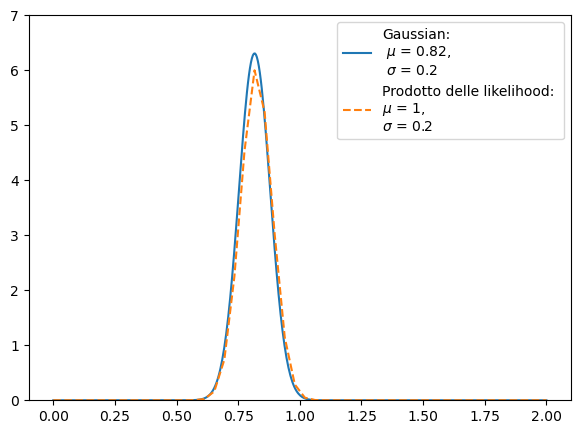

In [279]:
fix, ax = plt.subplots(figsize = (7,5))
x = np.linspace(0, 2, 500)

valid = err_fisher[~np.isnan(err_fisher)]


gauss = norm(solution, np.max(valid))
plt.plot(x, gauss.pdf(x), label = f'Gaussian:\n $\mu$ = {solution:.2}, \n $\sigma$ = {np.max(valid*np.sqrt(N)):.2}')
plt.plot(xplot, prod*6, ls='dashed', label = f'Prodotto delle likelihood: \n$\mu$ = {mu}, \n$\sigma$ = {sigma}')
plt.ylim(0,7)
plt.legend(loc='upper right')